### **Topic: Document Loaders in LangChain**

#### **1. What are Document Loaders?**

Document Loaders are fundamental components in LangChain used to load data from various sources. Their primary job is to take data from different locations and formats (like PDFs, text files, websites, or databases) and convert it into a **standardized format** that the rest of the LangChain framework can understand.

This standardized format is called a **Document object**.

**Key Characteristics of a Document Object:**
*   **`page_content`**: This holds the actual textual content of the data.
*   **`metadata`**: This is a dictionary containing descriptive information about the data, such as the source (file name or URL), page number, author, or creation date.

> **Important:** Regardless of which loader you use, the output will always be a **list of Document objects**. Even if you load a single text file, you will get a list containing one Document object.

#### **2. The Four Most Common Document Loaders**

This section covers the four most frequently used loaders, demonstrated with code and expected outputs.

### **Topic: JSON Loader in LangChain**

#### **1. What is the JSONLoader?**

The `JSONLoader` is a document loader in LangChain designed to load data from JSON (JavaScript Object Notation) files and JSON Lines files .

Its key feature is its flexibility. Unlike simpler loaders, it doesn't just load the entire file as one document. Instead, it uses a **`jq_schema`** to parse the JSON and extract specific pieces of data, creating one `Document` object for each selected element . This is extremely powerful for working with structured data.

**Key Concepts:**
*   **`jq_schema` (Required)**: A string that defines a query using the `jq` syntax. This query tells the loader exactly which parts of the JSON to extract. Think of it as a path or filter for your JSON data .
*   **`json_lines` (Optional)**: Set this to `True` if you are loading a JSON Lines file (`.jsonl`), where each line is a separate JSON object .
*   **`content_key` (Optional)**: If the `jq_schema` returns a list of objects (dictionaries), you can use `content_key` to specify which key from those objects should be used as the `page_content` .
*   **`metadata_func` (Optional)**: A custom function you can write to extract and add metadata from the JSON object to the resulting `Document`'s metadata field .

> **Installation Note**: The `JSONLoader` relies on the `jq` Python package. You may need to install it:
> ```bash
> pip install jq
> ```
> 

#### **2. How it Works: `jq_schema` in Action**

The `jq_schema` is the heart of the JSONLoader. It determines how the JSON is broken down into documents.

##### **A. Loading All String Values (No Specific Pointer)**

If you don't use a specific pointer, the loader will find and load **all string values** it encounters in the JSON object, creating one document per string .

**Example JSON (`simple.json`):**
```json
{
  "texts": ["This is a sentence.", "This is another sentence."],
  "nestedTexts": {
    "one": "This is a sentence nested in an object."
  }
}
```

**Code:**
```python
from langchain_community.document_loaders import JSONLoader

loader = JSONLoader(
    file_path="simple.json",
    jq_schema="."  # A simple '.' means "operate on the whole JSON"
)

docs = loader.load()

for i, doc in enumerate(docs):
    print(f"--- Document {i+1} ---")
    print(f"Content: {doc.page_content}")
    print(f"Metadata: {doc.metadata}\n")
```

**Output:**
```
--- Document 1 ---
Content: This is a sentence.
Metadata: {'source': 'simple.json', 'seq_num': 1}

--- Document 2 ---
Content: This is another sentence.
Metadata: {'source': 'simple.json', 'seq_num': 2}

--- Document 3 ---
Content: This is a sentence nested in an object.
Metadata: {'source': 'simple.json', 'seq_num': 3}
```
*Notice how it extracted all three strings from different parts of the JSON.* 

##### **B. Extracting Specific Content from a List of Objects**

This is the most common and powerful use case. You use `jq_schema` to target a specific field within a list of objects.

**Example JSON (`facebook_chat.json`):**
```json
{
  "messages": [
    { "content": "Bye!", "sender_name": "User 2" },
    { "content": "Oh no worries! Bye", "sender_name": "User 1" },
    { "content": "No Im sorry it was my mistake...", "sender_name": "User 2" }
  ],
  "participants": [{"name": "User 1"}, {"name": "User 2"}]
}
```

**Code:**
```python
from langchain_community.document_loaders import JSONLoader

loader = JSONLoader(
    file_path="facebook_chat.json",
    jq_schema=".messages[].content",  # Extract the 'content' field from every object in the 'messages' list
    text_content=False
)

docs = loader.load()

for i, doc in enumerate(docs):
    print(f"--- Document {i+1} ---")
    print(f"Content: {doc.page_content}")
    print(f"Metadata: {doc.metadata}\n")
```

**Output:**
```
--- Document 1 ---
Content: Bye!
Metadata: {'source': 'facebook_chat.json', 'seq_num': 1}

--- Document 2 ---
Content: Oh no worries! Bye
Metadata: {'source': 'facebook_chat.json', 'seq_num': 2}

--- Document 3 ---
Content: No Im sorry it was my mistake...
Metadata: {'source': 'facebook_chat.json', 'seq_num': 3}
```
*The loader created one document per message, using the `content` field as the `page_content`.* 

#### **3. Advanced: Using `content_key`**

Sometimes your `jq_schema` might select entire objects, and you need to specify which key within those objects holds the text content.

**Example JSON (`data.json`):**
```json
{"data": [
    {"attributes": {"message": "Hello", "tags": ["tag1"]}, "id": "1"},
    {"attributes": {"message": "World", "tags": ["tag2"]}, "id": "2"}
]}
```

**Code:**
```python
loader = JSONLoader(
    file_path="data.json",
    jq_schema=".data[]",          # Select each object in the 'data' array
    content_key=".attributes.message", # From each object, use the value at .attributes.message as content
    is_content_key_jq_parsable=True # Indicate that content_key is also a jq path
)

docs = loader.load()
for doc in docs:
    print(doc.page_content)
```

**Output:**
```
Hello
World
```
*Here, `jq_schema` selected two objects. The `content_key` then told the loader to look inside each object and use the value at `.attributes.message` as the page content.* 

#### **4. Working with JSON Lines (`.jsonl`)**

JSON Lines files have one valid JSON value per line. You enable this by setting `json_lines=True`.

**Example File (`messages.jsonl`):**
```jsonl
{"sender_name": "User 2", "content": "Bye!"}
{"sender_name": "User 1", "content": "Oh no worries! Bye"}
{"sender_name": "User 2", "content": "No Im sorry it was my mistake..."}
```

**Code:**
```python
loader = JSONLoader(
    file_path="messages.jsonl",
    jq_schema=".content",  # Extract the 'content' field from each line's JSON object
    json_lines=True,
    text_content=False
)

docs = loader.load()
for i, doc in enumerate(docs):
    print(f"Document {i+1} content: {doc.page_content}")
```

**Output:**
```
Document 1 content: Bye!
Document 2 content: Oh no worries! Bye
Document 3 content: No Im sorry it was my mistake...
```
*The loader processes each line independently, applying the `jq_schema` to it.* 

#### **5. Extracting Metadata with a Custom Function**

You can create a custom function to add specific fields from your JSON as metadata to each document.

**Example:**
Let's say we want the `id` from the `data.json` example above to be included as metadata.

**Code:**
```python
import json
from langchain_community.document_loaders import JSONLoader
from langchain_core.documents import Document

# Define a custom metadata function
def custom_metadata(record: dict, metadata: dict) -> dict:
    """Adds the 'id' field from the JSON record to the document's metadata."""
    metadata["id"] = record.get("id")
    return metadata

loader = JSONLoader(
    file_path="data.json",
    jq_schema=".data[]",
    content_key=".attributes.message",
    is_content_key_jq_parsable=True,
    metadata_func=custom_metadata  # Pass our custom function
)

docs = loader.load()
for doc in docs:
    print(f"Content: {doc.page_content}")
    print(f"Metadata: {doc.metadata}\n")
```

**Output:**
```
Content: Hello
Metadata: {'source': 'data.json', 'seq_num': 1, 'id': '1'}

Content: World
Metadata: {'source': 'data.json', 'seq_num': 2, 'id': '2'}
```
*The `id` from each JSON object has been successfully added to the metadata of its corresponding Document.* 

#### **6. Summary: JSON Loader at a Glance**

*   **Purpose**: Load structured data from JSON/JSONL files into LangChain `Document` objects.
*   **Core Concept**: Uses a powerful `jq_schema` to precisely define which data to extract.
*   **Granularity**: Creates one `Document` per element selected by the `jq_schema` (e.g., one per object in an array, one per line in a JSONL file).
*   **Flexibility**: Allows custom metadata extraction via the `metadata_func` parameter.
*   **Use Cases**: Ideal for loading chat logs, API responses, configuration files, or any structured data where you need to convert specific fields into a text format for use in RAG pipelines or other LLM applications .

#### **4. Summary and Key Takeaways**

1.  **Document Loaders are the entry point** for any RAG (Retrieval-Augmented Generation) application in LangChain.
2.  They standardize data from diverse sources (PDFs, web, CSVs, etc.) into a uniform **`Document` object** (with `page_content` and `metadata`).
3.  The output of any loader is always a **list of Documents**.
4.  **`PyPDFLoader`** is excellent for text-based PDFs, creating one document per page.
5.  **`WebBaseLoader`** is perfect for scraping and loading static web pages.
6.  **`CSVLoader`** creates a document for each row in your spreadsheet.
7.  **`DirectoryLoader`** helps load many files from a folder in one go.
8.  Use **`loader.load()`** for smaller datasets. For massive datasets, use **`loader.lazy_load()`** to process documents in a memory-efficient way.
9.  LangChain has hundreds of other loaders for platforms like YouTube, Twitter, databases, and cloud storage. The basic principles you learned here apply to all of them. You can even create **custom loaders** if you have a unique data source.

In [1]:
# pip install jq

##### Example JSON File (legal_qa.json):

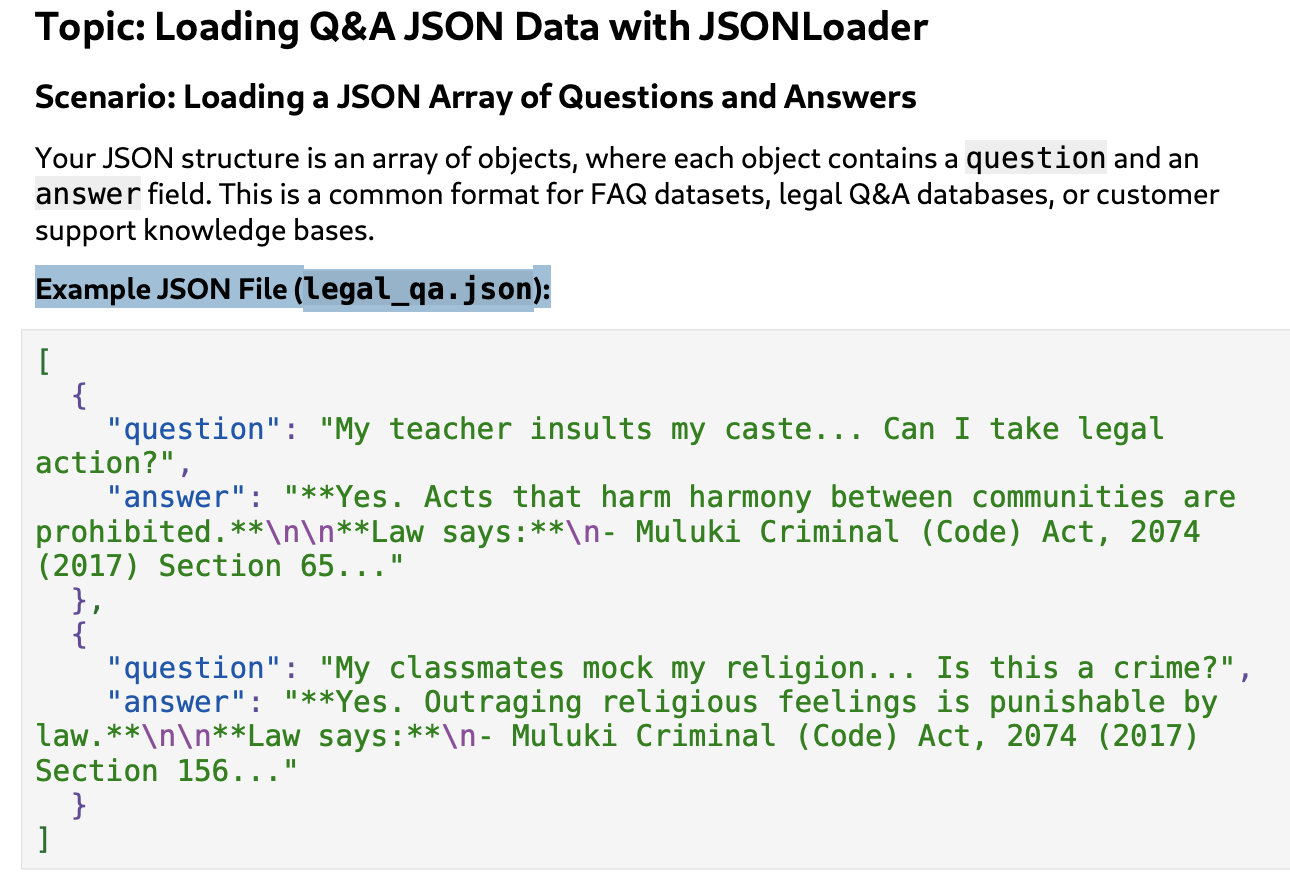

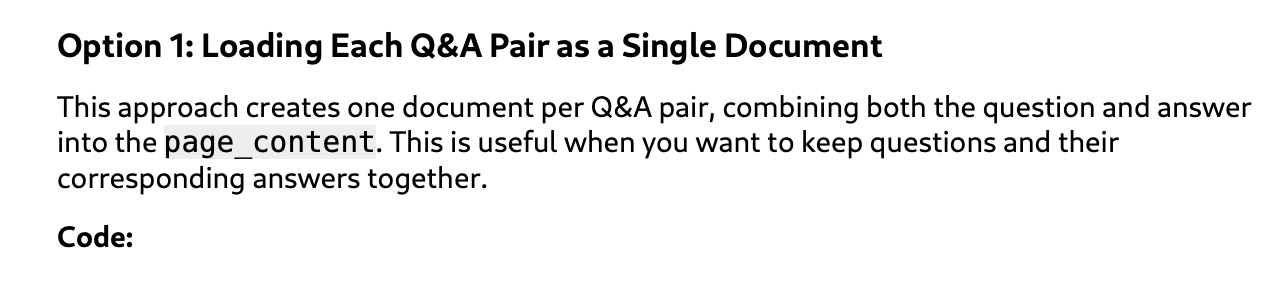

In [4]:
from langchain_community.document_loaders import JSONLoader
import json

# Extract both question and answer fields, combining them into document content
loader = JSONLoader(
    file_path="./6_cleaned_socialInclusion.json",
    jq_schema='.[] | "Question: " + .question + "\n\nAnswer: " + .answer',
    text_content=False,
)



####  load all the documents

In [6]:
docs=loader.load()

In [7]:
print(f"Number of documents: {len(docs)}")

Number of documents: 1009


In [8]:
type(docs)

list

#### Examine the first document

In [10]:
first_doc=docs[0]
print(first_doc)

page_content='Question: My teacher insults my caste in front of other students and creates hatred in the classroom. Can I take legal action?

Answer: **Yes. Acts that harm harmony between communities are prohibited.**

**Law says:**
- Muluki Criminal (Code) Act, 2074 (2017) Section 65: Prohibition of acts on the ground of caste or community that are prejudicial to harmonious relationships.

**Punishment:**
- Imprisonment for a term not exceeding one year and a fine not exceeding ten thousand rupees.

**What to do:**
1. Write down dates, words used, and names of student witnesses.
2. File a complaint at the nearest police office.' metadata={'source': '/Users/kristalshrestha/Documents/Code/LLM_Scratch/Langchain/6_RAG/1_document_loader/6_cleaned_socialInclusion.json', 'seq_num': 1}


In [11]:
first_doc.page_content

'Question: My teacher insults my caste in front of other students and creates hatred in the classroom. Can I take legal action?\n\nAnswer: **Yes. Acts that harm harmony between communities are prohibited.**\n\n**Law says:**\n- Muluki Criminal (Code) Act, 2074 (2017) Section 65: Prohibition of acts on the ground of caste or community that are prejudicial to harmonious relationships.\n\n**Punishment:**\n- Imprisonment for a term not exceeding one year and a fine not exceeding ten thousand rupees.\n\n**What to do:**\n1. Write down dates, words used, and names of student witnesses.\n2. File a complaint at the nearest police office.'